In [1]:
from vertcohirf.experiment.custom_experiment import (
    HPOCustomCoClusteringExperiment,
)
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from pathlib import Path
import pandas as pd
import seaborn as sns
import joblib
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from itertools import product
import contextlib

In [2]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar given as argument"""

    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback


def _generate_simplex_vertices(n_clusters, n_features, distance, seed):
    # Step 1: create a simplex in R^(n_clusters-1) using orthonormalized Gram matrix
    # Start with identity and subtract the centroid projection

    if n_clusters > n_features + 1:
        raise ValueError("Impossible configuration: need n_clusters ≤ n_features+1 for equal pairwise distances.")

    A = np.eye(n_clusters) - np.ones((n_clusters, n_clusters)) / n_clusters

    # Step 2: take first n_features columns (or all if n_clusters-1 == n_features)
    # And do eigen-decomposition to get embedding
    vals, vecs = np.linalg.eigh(A)
    coords = vecs[:, 1:n_clusters] * np.sqrt(vals[1:n_clusters])

    # coords is n_clusters × (n_clusters-1). Embed into R^n_features by padding with zeros if needed.
    if n_features > n_clusters - 1:
        coords = np.pad(coords, ((0, 0), (0, n_features - (n_clusters - 1))))
    # Step 3: scale so that pairwise distances are exactly d
    # Current simplex has distance sqrt(2)
    coords *= distance / np.sqrt(2)

    # Step 4: random rotation in R^n_features
    rng = np.random.default_rng(seed)
    random_matrix = rng.normal(size=(n_features, n_features))
    Q, R = np.linalg.qr(random_matrix)
    coords = coords @ Q

    return coords


def generate_simplex_data(
    n_clusters: int = 3,
    n_features: int = 3,
    n_shared_features: int = 0,
    distance: float = 10.0,
    seed: int = 42,
    std: float | list[float] = 1.0,
    # cor: float | list[float] | None = None,
    standardize: bool = False,
    samples_per_cluster: int | list[int] = 100,
):
    """
    Generate n-dimensional clustered data with configurable parameters.

    Parameters:
    -----------
    n_clusters : int, default=3
        Number of clusters to generate
    n_features : int, default=3
        Total number of features/dimensions
    n_shared_features : int, default=2
        Number of features that are shared (same value) across all cluster centers
    distance : float, default=10
        Minimum pairwise distance between cluster centers in the non-shared dimensions
    seed : int, default=42
        Random seed for reproducibility
    std : float, default=1
        Standard deviation for the multivariate normal distribution
    standardize : bool, default=False
        Whether to standardize the data
    samples_per_cluster : int, default=100
        Number of samples per cluster

    Returns:
    --------
    X : ndarray of shape (n_clusters * samples_per_cluster, n_features)
        Feature matrix
    y : ndarray of shape (n_clusters * samples_per_cluster,)
        Labels
    centers : ndarray of shape (n_clusters, n_features)
        Cluster centers
    """
    rng = np.random.default_rng(seed)

    if n_shared_features >= n_features:
        raise ValueError("n_shared_features must be less than n_features")

    if n_clusters < 2:
        raise ValueError("n_clusters must be at least 2")

    # Generate shared coordinates (same for all clusters)
    shared_coords = rng.random(n_shared_features)

    n_varying_features = n_features - n_shared_features

    varying_centers = _generate_simplex_vertices(n_clusters, n_varying_features, distance, seed)

    # Combine shared and varying coordinates
    centers = []
    for varying_coords in varying_centers:
        center = np.concatenate([shared_coords, varying_coords])
        centers.append(center)

    centers = np.array(centers)

    # Generate covariance matrix
    if isinstance(std, list):
        if len(std) != n_features:
            raise ValueError("Length of std list must match n_features")
        cov = np.diag(np.array(std) ** 2)
    else:
        cov = np.eye(n_features) * std**2

    # Generate samples
    X = []
    y = []
    if isinstance(samples_per_cluster, list):
        if len(samples_per_cluster) != n_clusters:
            raise ValueError("Length of samples_per_cluster list must match n_clusters")

    for i, center in enumerate(centers):
        if isinstance(samples_per_cluster, list):
            samples_per_cluster_i = samples_per_cluster[i]
        else:
            samples_per_cluster_i = samples_per_cluster
        samples = rng.multivariate_normal(center, cov, size=samples_per_cluster_i)
        X.append(samples)
        y += [i] * samples_per_cluster_i

    X = np.vstack(X)
    y = np.array(y)

    # Shuffle the dataset
    indices = rng.permutation(len(X))
    X = X[indices]
    y = y[indices]

    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)

    return X, y, centers


def run_single_experiment(
    seed,
    std,
    n_clusters,
    n_features,
    n_shared_features,
    distance,
    standardize,
    samples_per_cluster,
    n_noise_features,
    n_agents,
    p_overlap,
    sequential_split,
    features_groups,
    model,
    model_params,
    n_trials,
    hpo_metric,
    direction,
    suffix_model="",
):
    X, y, centers = generate_simplex_data(
        n_clusters=n_clusters,
        n_features=n_features,
        n_shared_features=n_shared_features,
        distance=distance,
        seed=seed,
        std=std,
        standardize=standardize,
        samples_per_cluster=samples_per_cluster,
    )
    # add random noise features
    rng = np.random.default_rng(seed)
    noise = rng.normal(size=(X.shape[0], n_noise_features))
    X = np.hstack([X, noise])
    X = pd.DataFrame(X)
    y = pd.Series(y)
    vecohirf_experiment = HPOCustomCoClusteringExperiment(
        # dataset
        X=X,
        y=y,
        n_agents=n_agents,
        p_overlap=p_overlap,
        sequential_split=sequential_split,
        features_groups=features_groups,
        # model
        model=model,
        model_params=model_params,
        n_trials=n_trials,
        # hpo
        hpo_seed=seed,
        hpo_metric=hpo_metric,
        direction=direction,
        calculate_metrics_even_if_too_many_clusters=True,
        # experiment
        raise_on_error=True,
        verbose=0,
    )
    vecohirf_result = vecohirf_experiment.run(return_results=True)[0]
    ari = vecohirf_result["evaluate_model_return"][f"best/{hpo_metric}"]
    result = {
        f"model{suffix_model}": model,
        "std": std,
        "ari": ari,
        "seed": seed,
        "n_features": n_features,
        "n_shared_features": n_shared_features,
        "distance": distance,
        "standardize": standardize,
        "n_noise_features": n_noise_features,
        "n_clusters": n_clusters,
        "n_agents": n_agents,
        "p_overlap": p_overlap,
        "sequential_split": sequential_split,
        "features_groups": features_groups,
        "samples_per_cluster": samples_per_cluster,
        "n_trials": n_trials,
        "hpo_metric": hpo_metric,
        "direction": direction,
    }
    return result

In [3]:
results_dir = Path("/home/belucci/code/vertcohirf/results/attack_rank")
results_dir.mkdir(parents=True, exist_ok=True)

In [4]:
n_clusters = 4
n_features = 6
n_shared_features = 0
distance = 1.0
seed = 42
std = 0.1
standardize = False
samples_per_cluster = int(1000 / n_clusters)
X, y, centers = generate_simplex_data(
    n_clusters=n_clusters,
    n_features=n_features,
    n_shared_features=n_shared_features,
    distance=distance,
    seed=seed,
    std=std,
    standardize=standardize,
    samples_per_cluster=samples_per_cluster,
)
# add random noise features
n_noise_features = 6
rng = np.random.default_rng(seed)
noise = rng.normal(size=(X.shape[0], n_noise_features))
X = np.hstack([X, noise])
X = pd.DataFrame(X)
y = pd.Series(y)

Text(0, 0.5, 't-SNE Component 2')

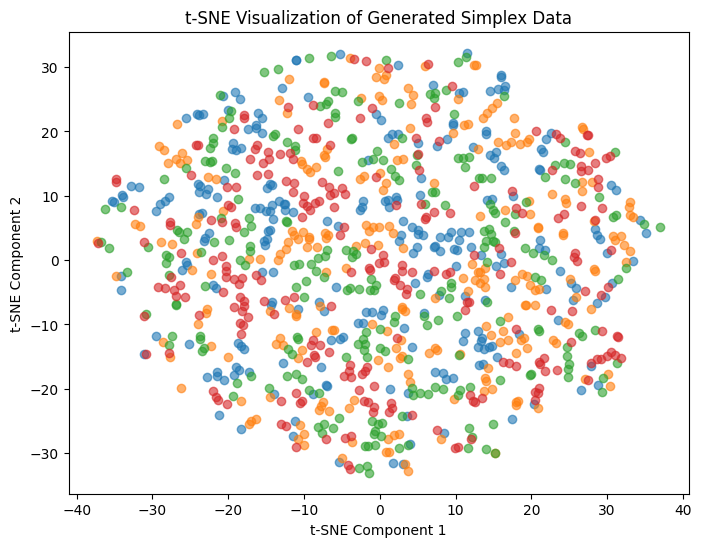

In [5]:
# visualize the data with t-SNE
tsne = TSNE(n_components=2, random_state=seed)
X_tsne = tsne.fit_transform(X)
colors = plt.colormaps["tab10"].colors
fig, ax = plt.subplots(figsize=(8, 6))
for i in range(n_clusters):
    ax.scatter(
        X_tsne[y == i, 0],
        X_tsne[y == i, 1],
        c=[colors[i % len(colors)]],
        label=f"Cluster {i}",
        alpha=0.6,
    )
plt.title('t-SNE Visualization of Generated Simplex Data')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

# Increase std

## 3 agents

In [6]:
n_clusters = 4
n_features = 3
n_shared_features = 0
distance = 1.0
# seed = 42
# std = 0.1
standardize = False
samples_per_cluster = int(1000 / n_clusters)
n_noise_features = 3
n_agents = 3
p_overlap = 0.0
sequential_split = False
n_trials = 20
n_trials_1 = 20
n_trials_2 = 10
direction = "maximize"
# equally split informative features among agents and distribute random features
features_groups = []
informative_features = list(range(n_features))
random_features = list(range(n_features, n_features + n_noise_features))
for agent_i in range(n_agents):
    agent_informative = informative_features[agent_i::n_agents]
    n_agent_informative = len(agent_informative)
    n_random_per_agent = len(random_features) // n_agents
    start_idx = agent_i * n_random_per_agent
    if agent_i == n_agents - 1:
        agent_random = random_features[start_idx:]
    else:
        agent_random = random_features[start_idx : start_idx + n_random_per_agent]
    features_groups.append(agent_informative + agent_random)

In [ ]:
stds = [0.1, 0.2, 0.4, 1.0]
seeds = [0, 1, 2, 3, 4]
combinations = []
for seed in seeds:
    for std in stds:
        combinations.append(dict(seed=seed, std=std))
results = []

In [9]:
model = "VeCoHiRF"
model_params = dict()
hpo_metric = "adjusted_rand_mean"

# Parallelize using joblib with progress bar
with tqdm_joblib(tqdm(total=len(combinations), desc="Processing datasets")) as progress_bar:
    results = Parallel(n_jobs=-1)(
        delayed(run_single_experiment)(
            combination["seed"],
            combination["std"],
            n_clusters,
            n_features,
            n_shared_features,
            distance,
            standardize,
            samples_per_cluster,
            n_noise_features,
            n_agents,
            p_overlap,
            sequential_split,
            features_groups,
            model,
            model_params,
            n_trials,
            hpo_metric,
            direction,
        )
        for combination in combinations
    )

Processing datasets:   0%|          | 0/8 [00:00<?, ?it/s]

In [ ]:
model = "VeCoHiRF"
model_params = dict(attack_on_rank="random", n_attack_on_rank_agents=1)
hpo_metric = "adjusted_rand_mean"
suffix_model = "-attacked"

# Parallelize using joblib with progress bar
with tqdm_joblib(tqdm(total=len(combinations), desc="Processing datasets")) as progress_bar:
    results = Parallel(n_jobs=-1)(
        delayed(run_single_experiment)(
            combination["seed"],
            combination["std"],
            n_clusters,
            n_features,
            n_shared_features,
            distance,
            standardize,
            samples_per_cluster,
            n_noise_features,
            n_agents,
            p_overlap,
            sequential_split,
            features_groups,
            model,
            model_params,
            n_trials,
            hpo_metric,
            direction,
            suffix_model=suffix_model,
        )
        for combination in combinations
    )

In [24]:
# save results to csv
results_df = pd.DataFrame(results)
results_df.to_csv(results_dir / "attack_rank_results.csv", index=False)

In [15]:
results_df = pd.read_csv(results_dir / "attack_rank_results.csv")

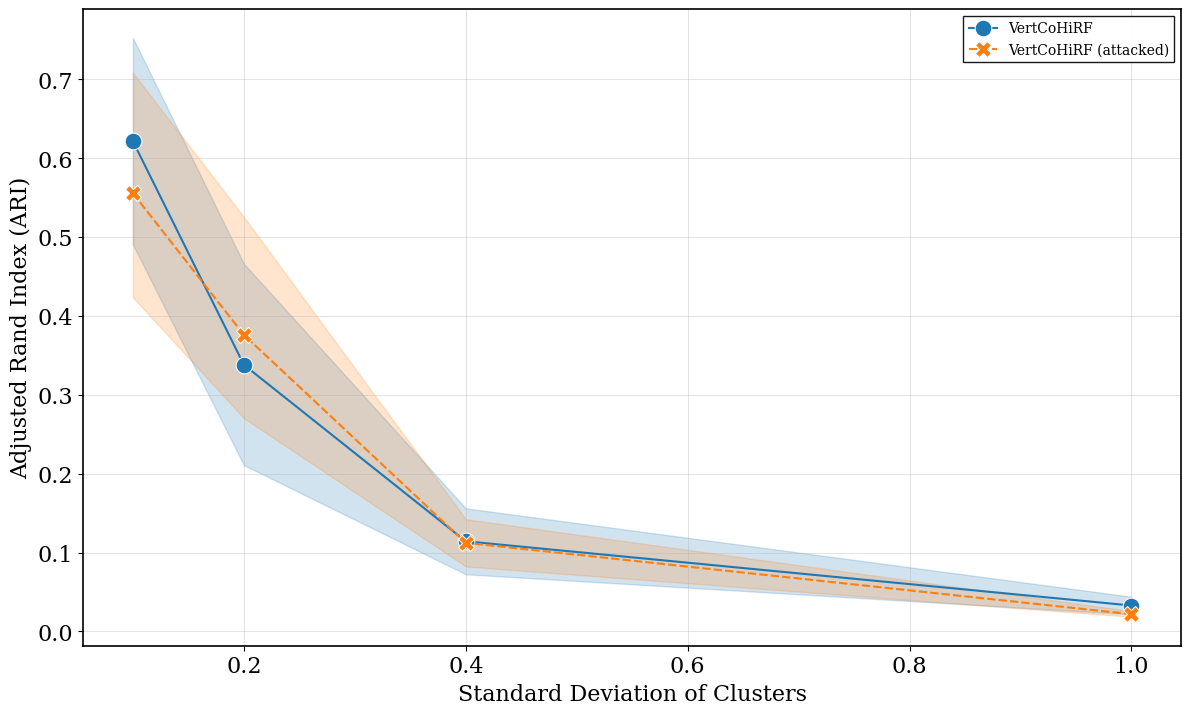

In [16]:
model_names = {
    "VeCoHiRF": "VertCoHiRF",
    "VeCoHiRF-attacked": "VertCoHiRF (attacked)",
}
results_df["model"] = results_df["model"].map(model_names)
with mpl.rc_context(
    rc={
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Liberation Serif", "Times", "serif"],  # Reliable serif fonts
        "mathtext.fontset": "dejavuserif",  # Use DejaVu for math text to avoid missing glyphs
        "axes.unicode_minus": False,  # Use ASCII minus instead of Unicode minus
        "font.size": 12,
        "axes.linewidth": 1.2,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 10,
        "legend.frameon": True,
        "legend.fancybox": False,
        "legend.shadow": False,
        "legend.framealpha": 0.9,
        "legend.edgecolor": "black",
        "grid.alpha": 0.5,
        "axes.grid": True,
        "grid.linewidth": 0.5,
    }
):
    cm = 1 / 2.54  # centimeters to inches
    fig_scale = 3.0
    fig, ax = plt.subplots(figsize=(12 * fig_scale * cm, 7 * fig_scale * cm))
    ax = sns.lineplot(
        data=results_df,
        x="std",
        y="ari",
        style="model",
        hue="model",
        markers=True,
        markersize=12,
        # marker="o",
        ax=ax,
    )
    ax.set_xlabel("Standard Deviation of Clusters")
    ax.set_ylabel("Adjusted Rand Index (ARI)")
    ax.legend(title="")
    fig.savefig(results_dir / "attack_rank_results.pdf", dpi=600, bbox_inches="tight")

# 8 features

In [4]:
n_clusters = 4
n_features = 8
n_shared_features = 0
distance = 4.0
# seed = 42
# std = 0.1
standardize = False
samples_per_cluster = int(500 / n_clusters)
n_noise_features = 8
n_agents = 2
p_overlap = 0.0
sequential_split = False
n_trials = 20
hpo_metric = "adjusted_rand_mean"
direction = "maximize"
# equally split informative features among agents and distribute random features
features_groups = []
informative_features = list(range(n_features))
random_features = list(range(n_features, n_features + n_noise_features))
for agent_i in range(n_agents):
    agent_informative = informative_features[agent_i::n_agents]
    n_agent_informative = len(agent_informative)
    n_random_per_agent = len(random_features) // n_agents
    start_idx = agent_i * n_random_per_agent
    if agent_i == n_agents - 1:
        agent_random = random_features[start_idx:]
    else:
        agent_random = random_features[start_idx : start_idx + n_random_per_agent]
    features_groups.append(agent_informative + agent_random)

In [5]:
stds = [0.1, 0.2, 0.4, 1.0]
seeds = [0, 1, 2, 3, 4]
combinations = []
for seed in seeds:
    for std in stds:
        combinations.append(dict(seed=seed, std=std))

In [30]:
model = "VeCoHiRF"
model_params = dict()

# Parallelize using joblib with progress bar
with tqdm_joblib(tqdm(total=len(combinations), desc="Processing datasets")) as progress_bar:
    results = Parallel(n_jobs=5)(
        delayed(run_single_experiment)(
            combination["seed"],
            combination["std"],
            n_clusters,
            n_features,
            n_shared_features,
            distance,
            standardize,
            samples_per_cluster,
            n_noise_features,
            n_agents,
            p_overlap,
            sequential_split,
            features_groups,
            model,
            model_params,
            n_trials,
            hpo_metric,
            direction,
        )
        for combination in combinations
    )

Processing datasets:   0%|          | 0/20 [00:00<?, ?it/s]

In [31]:
results_df = pd.DataFrame(results)
results_df.to_csv(results_dir / "attack_rank_results_8features.csv", index=False)

In [9]:
results_df_all = pd.read_csv(results_dir / "attack_rank_results_8features.csv")

In [32]:
results_df

,model,std,ari,seed,n_features,n_shared_features,distance,standardize,n_noise_features,n_clusters,n_agents,p_overlap,sequential_split,features_groups,samples_per_cluster,n_trials,hpo_metric,direction
0,VeCoHiRF,0.1,1.000000,0,8,0,4.0,False,8,4,2,0.0,False,"[[0, 2, 4, 6, 8, 9, 10, 11], [1, 3, 5, 7, 12, ...",125,20,adjusted_rand_mean,maximize
1,VeCoHiRF,0.2,1.000000,0,8,0,4.0,False,8,4,2,0.0,False,"[[0, 2, 4, 6, 8, 9, 10, 11], [1, 3, 5, 7, 12, ...",125,20,adjusted_rand_mean,maximize
2,VeCoHiRF,0.4,0.971569,0,8,0,4.0,False,8,4,2,0.0,False,"[[0, 2, 4, 6, 8, 9, 10, 11], [1, 3, 5, 7, 12, ...",125,20,adjusted_rand_mean,maximize
3,VeCoHiRF,1.0,0.469801,0,8,0,4.0,False,8,4,2,0.0,False,"[[0, 2, 4, 6, 8, 9, 10, 11], [1, 3, 5, 7, 12, ...",125,20,adjusted_rand_mean,maximize
4,VeCoHiRF,0.1,0.714214,1,8,0,4.0,False,8,4,2,0.0,False,"[[0, 2, 4, 6, 8, 9, 10, 11], [1, 3, 5, 7, 12, ...",125,20,adjusted_rand_mean,maximize
5,VeCoHiRF,0.2,0.997335,1,8,0,4.0,False,8,4,2,0.0,False,"[[0, 2, 4, 6, 8, 9, 10, 11], [1, 3, 5, 7, 12, ...",125,20,adjusted_rand_mean,maximize
6,VeCoHiRF,0.4,0.997335,1,8,0,4.0,False,8,4,2,0.0,False,"[[0, 2, 4, 6, 8, 9, 10, 11], [1, 3, 5, 7, 12, ...",125,20,adjusted_rand_mean,maximize
7,VeCoHiRF,1.0,0.462737,1,8,0,4.0,False,8,4,2,0.0,False,"[[0, 2, 4, 6, 8, 9, 10, 11], [1, 3, 5, 7, 12, ...",125,20,adjusted_rand_mean,maximize
8,VeCoHiRF,0.1,0.761019,2,8,0,4.0,False,8,4,2,0.0,False,"[[0, 2, 4, 6, 8, 9, 10, 11], [1, 3, 5, 7, 12, ...",125,20,adjusted_rand_mean,maximize
9,VeCoHiRF,0.2,0.927573,2,8,0,4.0,False,8,4,2,0.0,False,"[[0, 2, 4, 6, 8, 9, 10, 11], [1, 3, 5, 7, 12, ...",125,20,adjusted_rand_mean,maximize


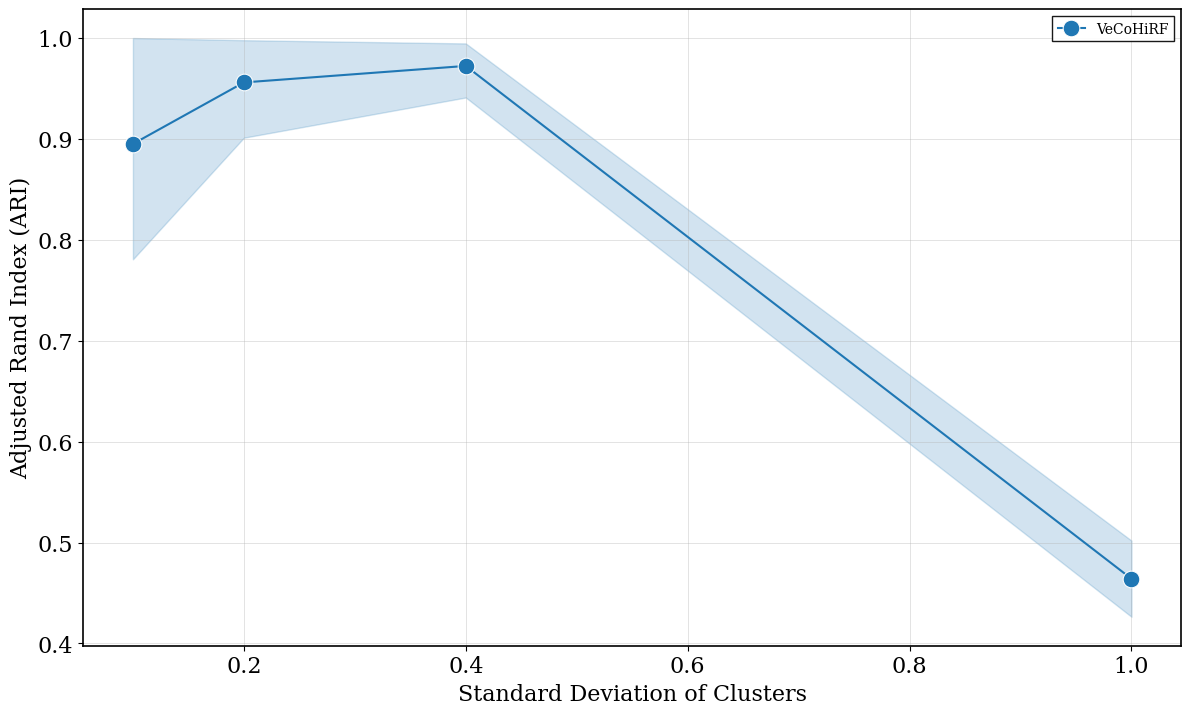

In [33]:
# model_names = {
#     "VeCoHiRF": "VertCoHiRF",
#     "VeCoHiRF-attacked": "VertCoHiRF (attacked)",
# }
# results_df["model"] = results_df["model"].map(model_names)
with mpl.rc_context(
    rc={
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Liberation Serif", "Times", "serif"],  # Reliable serif fonts
        "mathtext.fontset": "dejavuserif",  # Use DejaVu for math text to avoid missing glyphs
        "axes.unicode_minus": False,  # Use ASCII minus instead of Unicode minus
        "font.size": 12,
        "axes.linewidth": 1.2,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 10,
        "legend.frameon": True,
        "legend.fancybox": False,
        "legend.shadow": False,
        "legend.framealpha": 0.9,
        "legend.edgecolor": "black",
        "grid.alpha": 0.5,
        "axes.grid": True,
        "grid.linewidth": 0.5,
    }
):
    cm = 1 / 2.54  # centimeters to inches
    fig_scale = 3.0
    fig, ax = plt.subplots(figsize=(12 * fig_scale * cm, 7 * fig_scale * cm))
    ax = sns.lineplot(
        data=results_df,
        x="std",
        y="ari",
        style="model",
        hue="model",
        markers=True,
        markersize=12,
        # marker="o",
        ax=ax,
    )
    ax.set_xlabel("Standard Deviation of Clusters")
    ax.set_ylabel("Adjusted Rand Index (ARI)")
    ax.legend(title="")
    plt.show()
    fig.savefig(results_dir / "attack_rank_results.pdf", dpi=600, bbox_inches="tight")

# Increase number of attack agents

In [6]:
def run_single_experiment_attack(
    n_honest_agents,
    n_attack_on_rank_agents,
    seed,
    std,
    n_clusters,
    n_features,
    n_shared_features,
    distance,
    standardize,
    samples_per_cluster,
    n_noise_features,
    p_overlap,
    sequential_split,
    features_groups,
    model,
    n_trials,
    hpo_metric,
    direction,
    suffix_model="",
    attack=True,
):
    if attack:
        model_params = dict(attack_on_rank="random", n_attack_on_rank_agents=n_attack_on_rank_agents)
    else:
        model_params = dict()
    n_agents = n_honest_agents + n_attack_on_rank_agents
    features_groups = []
    informative_features = list(range(n_features))
    random_features = list(range(n_features, n_features + n_noise_features))
    for agent_i in range(n_agents):
        agent_informative = informative_features[agent_i::n_agents]
        n_agent_informative = len(agent_informative)
        n_random_per_agent = len(random_features) // n_agents
        start_idx = agent_i * n_random_per_agent
        if agent_i == n_agents - 1:
            agent_random = random_features[start_idx:]
        else:
            agent_random = random_features[start_idx : start_idx + n_random_per_agent]
        features_groups.append(agent_informative + agent_random)
    X, y, centers = generate_simplex_data(
        n_clusters=n_clusters,
        n_features=n_features,
        n_shared_features=n_shared_features,
        distance=distance,
        seed=seed,
        std=std,
        standardize=standardize,
        samples_per_cluster=samples_per_cluster,
    )
    # add random noise features
    rng = np.random.default_rng(seed)
    noise = rng.normal(size=(X.shape[0], n_noise_features))
    X = np.hstack([X, noise])
    X = pd.DataFrame(X)
    y = pd.Series(y)
    vecohirf_experiment = HPOCustomCoClusteringExperiment(
        # dataset
        X=X,
        y=y,
        n_agents=n_agents,
        p_overlap=p_overlap,
        sequential_split=sequential_split,
        features_groups=features_groups,
        # model
        model=model,
        model_params=model_params,
        n_trials=n_trials,
        # hpo
        hpo_seed=seed,
        hpo_metric=hpo_metric,
        direction=direction,
        calculate_metrics_even_if_too_many_clusters=True,
        # experiment
        raise_on_error=True,
        verbose=0,
    )
    vecohirf_result = vecohirf_experiment.run(return_results=True)[0]
    ari = vecohirf_result["evaluate_model_return"][f"best/{hpo_metric}"]
    result = {
        f"model{suffix_model}": model,
        "std": std,
        "ari": ari,
        "seed": seed,
        "n_features": n_features,
        "n_shared_features": n_shared_features,
        "distance": distance,
        "standardize": standardize,
        "n_noise_features": n_noise_features,
        "n_clusters": n_clusters,
        "n_agents": n_agents,
        "p_overlap": p_overlap,
        "sequential_split": sequential_split,
        "features_groups": features_groups,
        "samples_per_cluster": samples_per_cluster,
        "n_trials": n_trials,
        "hpo_metric": hpo_metric,
        "direction": direction,
        "n_honest_agents": n_honest_agents,
        "n_attack_on_rank_agents": n_attack_on_rank_agents,
        "attack": attack,
    }
    return result

In [7]:
n_clusters = 4
n_features = 8
n_shared_features = 0
distance = 4.0
# seed = 42
# std = 0.1
standardize = False
samples_per_cluster = int(500 / n_clusters)
n_noise_features = 8
p_overlap = 0.0
sequential_split = False
n_trials = 20
hpo_metric = "adjusted_rand_mean"
direction = "maximize"

In [8]:
stds = [0.4, 1.0]
seeds = [0, 1, 2, 3, 4]
n_attack_on_rank_agents_list = [1, 2, 3, 4, 5, 6]
combinations = []
for seed in seeds:
    for std in stds:
        for n_attack_on_rank_agents in n_attack_on_rank_agents_list:
            combinations.append(dict(seed=seed, std=std, n_attack_on_rank_agents=n_attack_on_rank_agents))

In [49]:
model = "VeCoHiRF"
model_params = dict()

# Parallelize using joblib with progress bar
with tqdm_joblib(tqdm(total=len(combinations), desc="Processing datasets")) as progress_bar:
    results = Parallel(n_jobs=5)(
        delayed(run_single_experiment_attack)(
            n_agents,
            combination["n_attack_on_rank_agents"],
            combination["seed"],
            combination["std"],
            n_clusters,
            n_features,
            n_shared_features,
            distance,
            standardize,
            samples_per_cluster,
            n_noise_features,
            p_overlap,
            sequential_split,
            features_groups,
            model,
            n_trials,
            hpo_metric,
            direction,
        )
        for combination in combinations
    )

Processing datasets:   0%|          | 0/60 [00:00<?, ?it/s]

In [50]:
# save results to csv
results_df = pd.DataFrame(results)
results_df.to_csv(results_dir / "attack_rank_n_agents_results.csv", index=False)

In [65]:
results_df = pd.read_csv(results_dir / "attack_rank_n_agents_results.csv")

In [9]:
model = "VeCoHiRF"

# Parallelize using joblib with progress bar
with tqdm_joblib(tqdm(total=len(combinations), desc="Processing datasets")) as progress_bar:
    results = Parallel(n_jobs=5)(
        delayed(run_single_experiment_attack)(
            n_agents,
            combination["n_attack_on_rank_agents"],
            combination["seed"],
            combination["std"],
            n_clusters,
            n_features,
            n_shared_features,
            distance,
            standardize,
            samples_per_cluster,
            n_noise_features,
            p_overlap,
            sequential_split,
            features_groups,
            model,
            n_trials,
            hpo_metric,
            direction,
            attack=False,
        )
        for combination in combinations
    )

Processing datasets:   0%|          | 0/60 [00:00<?, ?it/s]

In [10]:
# save results to csv
results_df = pd.DataFrame(results)
results_df.to_csv(results_dir / "no_attack_rank_n_agents_results.csv", index=False)

In [11]:
results_df

,model,std,ari,seed,n_features,n_shared_features,distance,standardize,n_noise_features,n_clusters,...,p_overlap,sequential_split,features_groups,samples_per_cluster,n_trials,hpo_metric,direction,n_honest_agents,n_attack_on_rank_agents,attack
0,VeCoHiRF,0.4,0.868548,0,8,0,4.0,False,8,4,...,0.0,False,"[[0, 3, 6, 8, 9], [1, 4, 7, 10, 11], [2, 5, 12...",125,20,adjusted_rand_mean,maximize,2,1,False
1,VeCoHiRF,0.4,0.480853,0,8,0,4.0,False,8,4,...,0.0,False,"[[0, 4, 8, 9], [1, 5, 10, 11], [2, 6, 12, 13],...",125,20,adjusted_rand_mean,maximize,2,2,False
2,VeCoHiRF,0.4,0.514089,0,8,0,4.0,False,8,4,...,0.0,False,"[[0, 5, 8], [1, 6, 9], [2, 7, 10], [3, 11], [4...",125,20,adjusted_rand_mean,maximize,2,3,False
3,VeCoHiRF,0.4,0.450746,0,8,0,4.0,False,8,4,...,0.0,False,"[[0, 6, 8], [1, 7, 9], [2, 10], [3, 11], [4, 1...",125,20,adjusted_rand_mean,maximize,2,4,False
4,VeCoHiRF,0.4,0.234659,0,8,0,4.0,False,8,4,...,0.0,False,"[[0, 7, 8], [1, 9], [2, 10], [3, 11], [4, 12],...",125,20,adjusted_rand_mean,maximize,2,5,False
5,VeCoHiRF,0.4,0.293288,0,8,0,4.0,False,8,4,...,0.0,False,"[[0, 8], [1, 9], [2, 10], [3, 11], [4, 12], [5...",125,20,adjusted_rand_mean,maximize,2,6,False
6,VeCoHiRF,1.0,0.351883,0,8,0,4.0,False,8,4,...,0.0,False,"[[0, 3, 6, 8, 9], [1, 4, 7, 10, 11], [2, 5, 12...",125,20,adjusted_rand_mean,maximize,2,1,False
7,VeCoHiRF,1.0,0.313309,0,8,0,4.0,False,8,4,...,0.0,False,"[[0, 4, 8, 9], [1, 5, 10, 11], [2, 6, 12, 13],...",125,20,adjusted_rand_mean,maximize,2,2,False
8,VeCoHiRF,1.0,0.179703,0,8,0,4.0,False,8,4,...,0.0,False,"[[0, 5, 8], [1, 6, 9], [2, 7, 10], [3, 11], [4...",125,20,adjusted_rand_mean,maximize,2,3,False
9,VeCoHiRF,1.0,0.085722,0,8,0,4.0,False,8,4,...,0.0,False,"[[0, 6, 8], [1, 7, 9], [2, 10], [3, 11], [4, 1...",125,20,adjusted_rand_mean,maximize,2,4,False


In [24]:
results_df_attack = pd.read_csv(results_dir / "attack_rank_n_agents_results.csv")
results_df_no_attack = pd.read_csv(results_dir / "no_attack_rank_n_agents_results.csv")
results_df_0 = pd.read_csv(results_dir / "attack_rank_results_8features.csv")
results_df_0["n_attack_on_rank_agents"] = 0
results_df_0["n_honest_agents"] = 2
results_df_0["attack"] = False
results_df_all = pd.concat([results_df_attack, results_df_no_attack, results_df_0], ignore_index=True)

In [25]:
results_df_all

,model,std,ari,seed,n_features,n_shared_features,distance,standardize,n_noise_features,n_clusters,...,p_overlap,sequential_split,features_groups,samples_per_cluster,n_trials,hpo_metric,direction,n_honest_agents,n_attack_on_rank_agents,attack
0,VeCoHiRF,0.4,0.402178,0,8,0,4.0,False,8,4,...,0.0,False,"[[0, 3, 6, 8, 9], [1, 4, 7, 10, 11], [2, 5, 12...",125,20,adjusted_rand_mean,maximize,2,1,True
1,VeCoHiRF,0.4,0.836745,0,8,0,4.0,False,8,4,...,0.0,False,"[[0, 4, 8, 9], [1, 5, 10, 11], [2, 6, 12, 13],...",125,20,adjusted_rand_mean,maximize,2,2,True
2,VeCoHiRF,0.4,0.567638,0,8,0,4.0,False,8,4,...,0.0,False,"[[0, 5, 8], [1, 6, 9], [2, 7, 10], [3, 11], [4...",125,20,adjusted_rand_mean,maximize,2,3,True
3,VeCoHiRF,0.4,0.416638,0,8,0,4.0,False,8,4,...,0.0,False,"[[0, 6, 8], [1, 7, 9], [2, 10], [3, 11], [4, 1...",125,20,adjusted_rand_mean,maximize,2,4,True
4,VeCoHiRF,0.4,0.249434,0,8,0,4.0,False,8,4,...,0.0,False,"[[0, 7, 8], [1, 9], [2, 10], [3, 11], [4, 12],...",125,20,adjusted_rand_mean,maximize,2,5,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,VeCoHiRF,1.0,0.530767,3,8,0,4.0,False,8,4,...,0.0,False,"[[0, 2, 4, 6, 8, 9, 10, 11], [1, 3, 5, 7, 12, ...",125,20,adjusted_rand_mean,maximize,2,0,False
136,VeCoHiRF,0.1,1.000000,4,8,0,4.0,False,8,4,...,0.0,False,"[[0, 2, 4, 6, 8, 9, 10, 11], [1, 3, 5, 7, 12, ...",125,20,adjusted_rand_mean,maximize,2,0,False
137,VeCoHiRF,0.2,0.994706,4,8,0,4.0,False,8,4,...,0.0,False,"[[0, 2, 4, 6, 8, 9, 10, 11], [1, 3, 5, 7, 12, ...",125,20,adjusted_rand_mean,maximize,2,0,False
138,VeCoHiRF,0.4,0.908914,4,8,0,4.0,False,8,4,...,0.0,False,"[[0, 2, 4, 6, 8, 9, 10, 11], [1, 3, 5, 7, 12, ...",125,20,adjusted_rand_mean,maximize,2,0,False


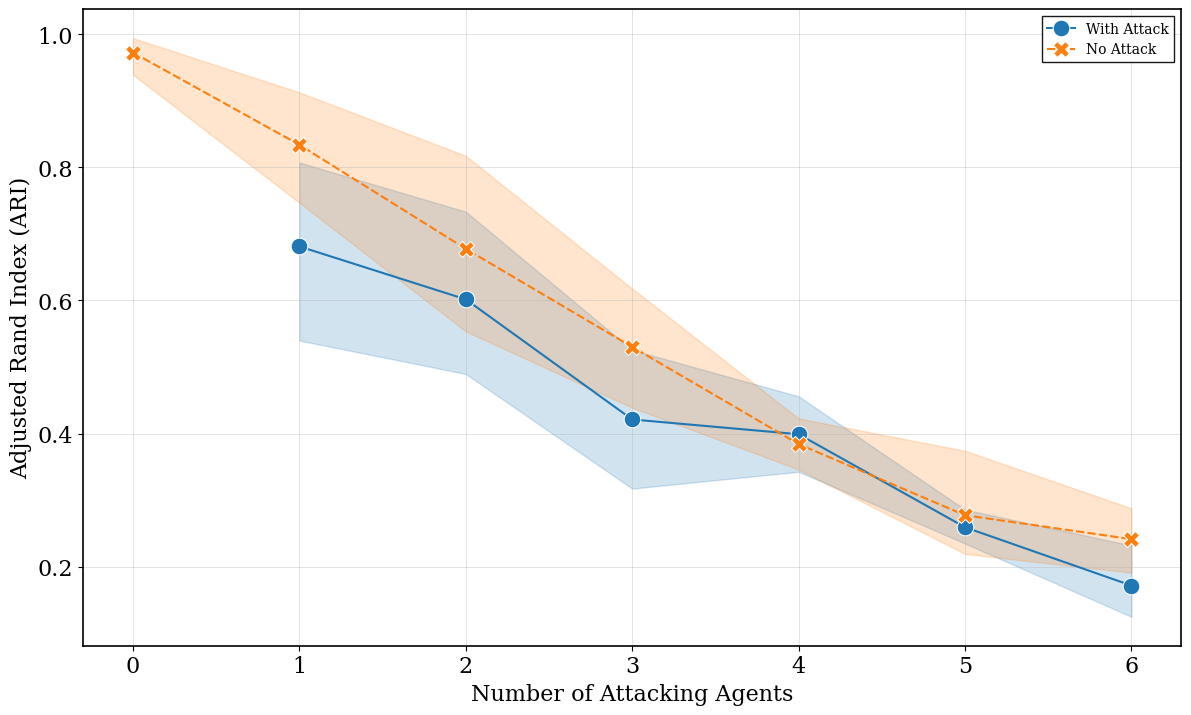

In [26]:
df_plot = results_df_all.copy()
std = 0.4
df_plot = df_plot[df_plot["std"] == std]
df_plot["std"] = df_plot["std"].astype(str)
df_plot["attack"] = df_plot["attack"].map({True: "With Attack", False: "No Attack"})
with mpl.rc_context(
    rc={
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Liberation Serif", "Times", "serif"],  # Reliable serif fonts
        "mathtext.fontset": "dejavuserif",  # Use DejaVu for math text to avoid missing glyphs
        "axes.unicode_minus": False,  # Use ASCII minus instead of Unicode minus
        "font.size": 12,
        "axes.linewidth": 1.2,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 10,
        "legend.frameon": True,
        "legend.fancybox": False,
        "legend.shadow": False,
        "legend.framealpha": 0.9,
        "legend.edgecolor": "black",
        "grid.alpha": 0.5,
        "axes.grid": True,
        "grid.linewidth": 0.5,
    }
):
    cm = 1 / 2.54  # centimeters to inches
    fig_scale = 3.0
    fig, ax = plt.subplots(figsize=(12 * fig_scale * cm, 7 * fig_scale * cm))
    ax = sns.lineplot(
        data=df_plot,
        x="n_attack_on_rank_agents",
        y="ari",
        style="attack",
        hue="attack",
        markers=True,
        markersize=12,
        # marker="o",
        ax=ax,
    )
    ax.set_xlabel("Number of Attacking Agents")
    ax.set_ylabel("Adjusted Rand Index (ARI)")
    ax.legend(title="")
    plt.show()
    fig.savefig(results_dir / f"attack_rank_n_agents_results_std_{std}.pdf", dpi=600, bbox_inches="tight")

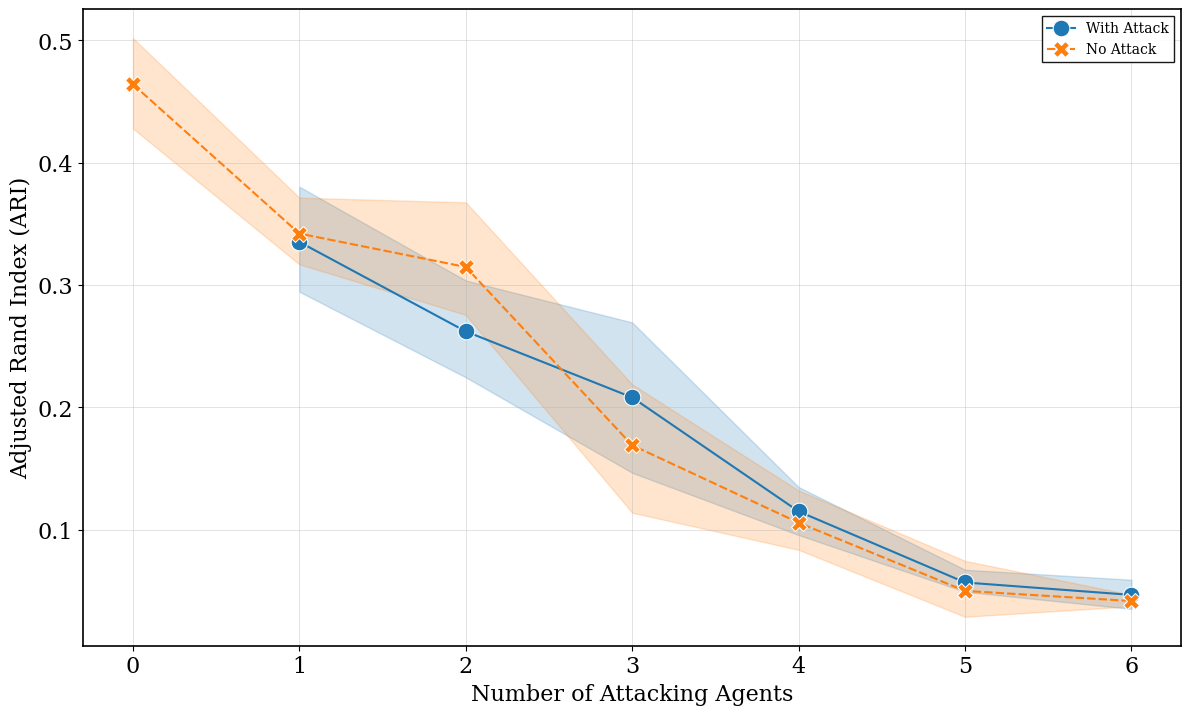

In [27]:
df_plot = results_df_all.copy()
std = 1.0
df_plot = df_plot[df_plot["std"] == std]
df_plot["std"] = df_plot["std"].astype(str)
df_plot["attack"] = df_plot["attack"].map({True: "With Attack", False: "No Attack"})
with mpl.rc_context(
    rc={
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Liberation Serif", "Times", "serif"],  # Reliable serif fonts
        "mathtext.fontset": "dejavuserif",  # Use DejaVu for math text to avoid missing glyphs
        "axes.unicode_minus": False,  # Use ASCII minus instead of Unicode minus
        "font.size": 12,
        "axes.linewidth": 1.2,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 10,
        "legend.frameon": True,
        "legend.fancybox": False,
        "legend.shadow": False,
        "legend.framealpha": 0.9,
        "legend.edgecolor": "black",
        "grid.alpha": 0.5,
        "axes.grid": True,
        "grid.linewidth": 0.5,
    }
):
    cm = 1 / 2.54  # centimeters to inches
    fig_scale = 3.0
    fig, ax = plt.subplots(figsize=(12 * fig_scale * cm, 7 * fig_scale * cm))
    ax = sns.lineplot(
        data=df_plot,
        x="n_attack_on_rank_agents",
        y="ari",
        style="attack",
        hue="attack",
        markers=True,
        markersize=12,
        # marker="o",
        ax=ax,
    )
    ax.set_xlabel("Number of Attacking Agents")
    ax.set_ylabel("Adjusted Rand Index (ARI)")
    ax.legend(title="")
    plt.show()
    fig.savefig(results_dir / f"attack_rank_n_agents_results_std_{std}.pdf", dpi=600, bbox_inches="tight")

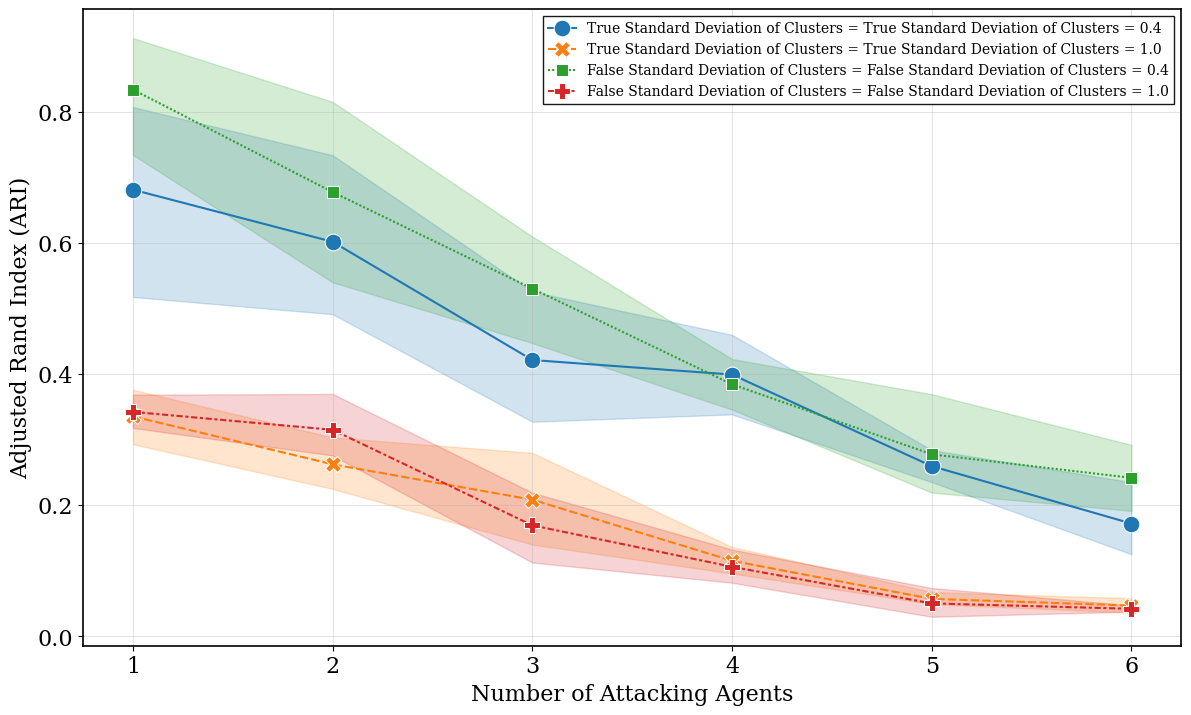

In [15]:
# model_names = {
#     "VeCoHiRF": "VertCoHiRF",
#     "VeCoHiRF-attacked": "VertCoHiRF (attacked)",
# }
# results_df["model"] = results_df["model"].map(model_names)
results_df_all["std"] = results_df_all["std"].astype(str)
results_df_all["std"] = results_df_all["attack"].astype(str) + " Standard Deviation of Clusters = " + results_df_all["std"]
with mpl.rc_context(
    rc={
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Liberation Serif", "Times", "serif"],  # Reliable serif fonts
        "mathtext.fontset": "dejavuserif",  # Use DejaVu for math text to avoid missing glyphs
        "axes.unicode_minus": False,  # Use ASCII minus instead of Unicode minus
        "font.size": 12,
        "axes.linewidth": 1.2,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 10,
        "legend.frameon": True,
        "legend.fancybox": False,
        "legend.shadow": False,
        "legend.framealpha": 0.9,
        "legend.edgecolor": "black",
        "grid.alpha": 0.5,
        "axes.grid": True,
        "grid.linewidth": 0.5,
    }
):
    cm = 1 / 2.54  # centimeters to inches
    fig_scale = 3.0
    fig, ax = plt.subplots(figsize=(12 * fig_scale * cm, 7 * fig_scale * cm))
    ax = sns.lineplot(
        data=results_df_all,
        x="n_attack_on_rank_agents",
        y="ari",
        style="std",
        hue="std",
        markers=True,
        markersize=12,
        # marker="o",
        ax=ax,
    )
    ax.set_xlabel("Number of Attacking Agents")
    ax.set_ylabel("Adjusted Rand Index (ARI)")
    ax.legend(title="")
    plt.show()
    fig.savefig(results_dir / "attack_rank_n_agents_results.pdf", dpi=600, bbox_inches="tight")